<a href="https://colab.research.google.com/github/MatheusRYSE/Analise-vendas/blob/main/vendas_treino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/VENDAS_TREINO.CSV")

In [ ]:
print(df.head())
print(df.info())
print(df.describe())

   cliente  idade          cidade   produto  valor  quantidade       data  mes
0      Ana     25       São Paulo  Notebook   3500           1 2024-01-10    1
1    Bruno     40  Rio de Janeiro     Mouse    100           2 2024-01-11    1
2   Carlos     35       São Paulo   Teclado    200           1 2024-01-12    1
3  Daniela     28  Belo Horizonte   Monitor   1200           2 2024-01-13    1
4  Eduardo     45       São Paulo  Notebook   4000           1 2024-01-14    1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   cliente     10 non-null     object        
 1   idade       10 non-null     int64         
 2   cidade      10 non-null     object        
 3   produto     10 non-null     object        
 4   valor       10 non-null     int64         
 5   quantidade  10 non-null     int64         
 6   data        10 non-null     datetime

In [ ]:
resultado = df.groupby("cliente")[["produto", "valor"]].sum()

print(resultado)

           produto  valor
cliente                  
Ana       Notebook   3500
Bruno        Mouse    100
Carlos     Teclado    200
Daniela    Monitor   1200
Eduardo   Notebook   4000
Fernanda     Mouse    150
Gabriel    Teclado    250
Helena     Monitor   1100
Igor      Notebook   4500
Juliana      Mouse    120


#Media de produto e valor

In [ ]:
media = df.groupby("produto")["valor"].mean()


print(media)

produto
Monitor     1150.000000
Mouse        123.333333
Notebook    4000.000000
Teclado      225.000000
Name: valor, dtype: float64


#Adicionando uma coluna nova "Total vendas"

In [ ]:
df["total_vendas"] = df["valor"] * df["quantidade"]

resultado = df.sort_values(by="total_vendas", ascending=False)

print(resultado)

    cliente  idade          cidade   produto  valor  quantidade        data  \
8      Igor     50       São Paulo  Notebook   4500           1  2024-01-18   
4   Eduardo     45       São Paulo  Notebook   4000           1  2024-01-14   
0       Ana     25       São Paulo  Notebook   3500           1  2024-01-10   
3   Daniela     28  Belo Horizonte   Monitor   1200           2  2024-01-13   
7    Helena     22  Belo Horizonte   Monitor   1100           1  2024-01-17   
6   Gabriel     38        Curitiba   Teclado    250           2  2024-01-16   
5  Fernanda     30  Rio de Janeiro     Mouse    150           3  2024-01-15   
9   Juliana     29        Curitiba     Mouse    120           2  2024-01-19   
1     Bruno     40  Rio de Janeiro     Mouse    100           2  2024-01-11   
2    Carlos     35       São Paulo   Teclado    200           1  2024-01-12   

   total_vendas  
8          4500  
4          4000  
0          3500  
3          2400  
7          1100  
6           500  
5   

In [ ]:
df.head(5)

,cliente,idade,cidade,produto,valor,quantidade,data,total_vendas
0,Ana,25,São Paulo,Notebook,3500,1,2024-01-10,3500
1,Bruno,40,Rio de Janeiro,Mouse,100,2,2024-01-11,200
2,Carlos,35,São Paulo,Teclado,200,1,2024-01-12,200
3,Daniela,28,Belo Horizonte,Monitor,1200,2,2024-01-13,2400
4,Eduardo,45,São Paulo,Notebook,4000,1,2024-01-14,4000


#Faturamento total

In [ ]:
print("Faturamento total", df["total_vendas"].sum())

Faturamento total 17090


#Top clientes

In [ ]:
top_clientes = df.groupby("cliente")["total_vendas"].sum().sort_values(ascending=False)

print(top_clientes.head(5))

cliente
Igor       4500
Eduardo    4000
Ana        3500
Daniela    2400
Helena     1100
Name: total_vendas, dtype: int64


Podemos verificar que o Mouse é o produto que mais temos no estoque.

In [ ]:
produtos = df.groupby("produto")["quantidade"].sum().sort_values(ascending=False)

print(produtos)

produto
Mouse       7
Monitor     3
Notebook    3
Teclado     3
Name: quantidade, dtype: int64


Podemos verificar que a cidade que mais vende é São Paulo.


In [ ]:
cidade = df.groupby("cidade")["total_vendas"].sum().sort_values(ascending=False)

print(cidade)

cidade
São Paulo         12200
Belo Horizonte     3500
Curitiba            740
Rio de Janeiro      650
Name: total_vendas, dtype: int64


Aqui podemos analisar vendas por data.

In [ ]:
vendas_tempo = df.groupby("data")["total_vendas"].sum()

print(vendas_tempo)

data
2024-01-10    3500
2024-01-11     200
2024-01-12     200
2024-01-13    2400
2024-01-14    4000
2024-01-15     450
2024-01-16     500
2024-01-17    1100
2024-01-18    4500
2024-01-19     240
Name: total_vendas, dtype: int64


Nessa parte podemos ver os clientes que mais compra e os que geram mais dinheiro.

In [ ]:
qtd = df.groupby("cliente")["quantidade"].sum()
valor = df.groupby("cliente")["total_vendas"].sum()

comparacao = pd.DataFrame({
    "quantidade" :qtd,
    "faturamento" :valor
}).sort_values(by="faturamento",ascending=False)

print(comparacao)


          quantidade  faturamento
cliente                          
Igor               1         4500
Eduardo            1         4000
Ana                1         3500
Daniela            2         2400
Helena             1         1100
Gabriel            2          500
Fernanda           3          450
Juliana            2          240
Bruno              2          200
Carlos             1          200


In [ ]:
qtd = df.groupby("cliente")["quantidade"].sum()
vendas = df.groupby("cliente")["total_vendas"].sum()
data = df.groupby("cliente")["data"]

comparacao = pd.DataFrame({
    "quantidade" :qtd,
    "faturamento" :vendas,
    "data" :data
}).sort_values(by="faturamento", ascending=False)

print(comparacao)

          quantidade  faturamento                      data
cliente                                                    
Igor               1         4500      (Igor, [2024-01-18])
Eduardo            1         4000   (Eduardo, [2024-01-14])
Ana                1         3500       (Ana, [2024-01-10])
Daniela            2         2400   (Daniela, [2024-01-13])
Helena             1         1100    (Helena, [2024-01-17])
Gabriel            2          500   (Gabriel, [2024-01-16])
Fernanda           3          450  (Fernanda, [2024-01-15])
Juliana            2          240   (Juliana, [2024-01-19])
Bruno              2          200     (Bruno, [2024-01-11])
Carlos             1          200    (Carlos, [2024-01-12])


In [ ]:
df["data"] = pd.to_datetime(df["data"])
df["total_vendas"] = df["valor"] * df["quantidade"]
df["mes"] = df["data"].dt.to_period("M")

vendas_mes = df.groupby("mes")["total_vendas"].sum()

print(vendas_mes)

mes
2024-01    17090
Freq: M, Name: total_vendas, dtype: int64


#Vou mostrar alguns graficos para melhores parametros e uma analise melhor

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

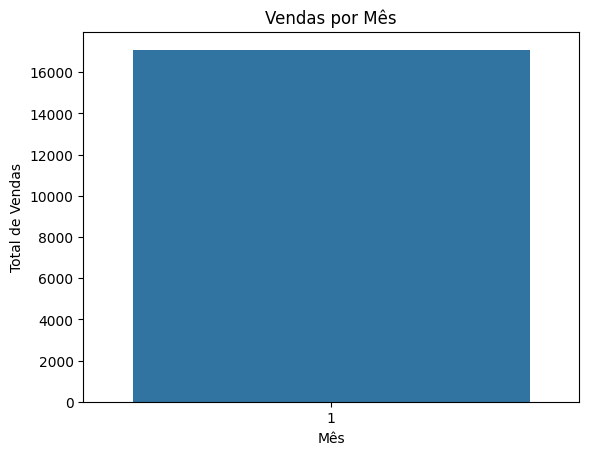


Nesse grafico conseguimos ver o faturamento total.


In [ ]:
vendas_mes = df.groupby("mes")["total_vendas"].sum()

plt.figure()
sns.barplot(x=vendas_mes.index, y=vendas_mes.values)
plt.title("Vendas por Mês")
plt.xlabel("Mês")
plt.ylabel("Total de Vendas")
plt.show()

print("\nNesse grafico conseguimos ver o faturamento total.")


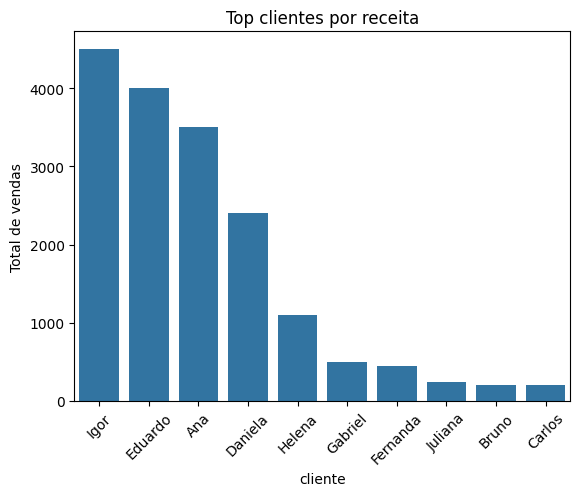


Aqui podemos ver um grafico com os melhores clientes.


In [ ]:
df["total_vendas"] = df["valor"] * df["quantidade"]
top_clientes = df.groupby("cliente")["total_vendas"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=top_clientes.index , y=top_clientes.values)
plt.title("Top clientes por receita")
plt.xlabel("cliente")
plt.ylabel("Total de vendas")
plt.xticks(rotation=45)
plt.show()

print("\nAqui podemos ver um grafico com os melhores clientes.")

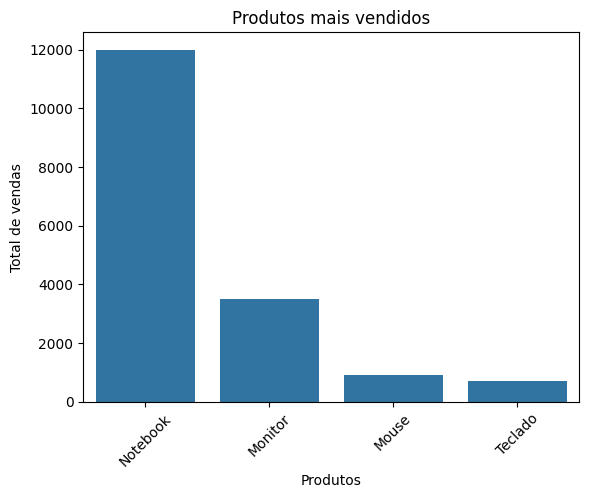


Aqui podemos ver os produtos mais vendidos.


In [ ]:
produtos = df.groupby("produto")["total_vendas"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=produtos.index, y=produtos.values)
plt.title("Produtos mais vendidos")
plt.xlabel("Produtos")
plt.ylabel("Total de vendas")
plt.xticks(rotation=45)
plt.show()

print("\nAqui podemos ver os produtos mais vendidos.")

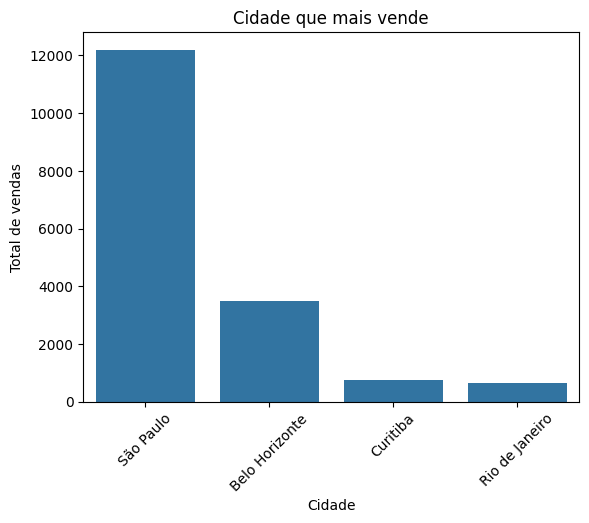


Nesse grafico podemos ver a cidade que mais vende.


In [ ]:
cidade = df.groupby("cidade")["total_vendas"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=cidade.index, y=cidade.values)
plt.title("Cidade que mais vende")
plt.xlabel("Cidade")
plt.ylabel("Total de vendas")
plt.xticks(rotation=45)
plt.show()

print("\nNesse grafico podemos ver a cidade que mais vende.")

In [ ]:
print("""
CONCLUSÃO:
- Identificamos os clientes mais valiosos
- Descobrimos os produtos mais rentáveis
- Observamos padrões de vendas ao longo do tempo
- Detectamos cidades com maior potencial

RECOMENDAÇÕES:
- Focar nos melhores clientes (retenção)
- Investir nos produtos mais vendidos
- Explorar cidades com alta receita
- Criar estratégias para meses de baixa venda
""")



CONCLUSÃO:
- Identificamos os clientes mais valiosos
- Descobrimos os produtos mais rentáveis
- Observamos padrões de vendas ao longo do tempo
- Detectamos cidades com maior potencial

RECOMENDAÇÕES:
- Focar nos melhores clientes (retenção)
- Investir nos produtos mais vendidos
- Explorar cidades com alta receita
- Criar estratégias para meses de baixa venda

